In [12]:
import numpy as np
import matplotlib.pyplot as plt
from run_experiment import *

In [13]:
quantum_ops_count = 0

def reset_quantum_ops():
    global quantum_ops_count
    quantum_ops_count = 0

In [14]:
def bellman_ford_classic(n, edges, start=0):
    """Классический BF: O(V*E)"""
    global quantum_ops_count
    reset_quantum_ops()
    
    dist = [float('inf')] * n
    dist[start] = 0
    
    for _ in range(n - 1):
        updated = False
        for u, v, w in edges:
            quantum_ops_count += 1 
            if dist[u] != float('inf') and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                updated = True
        if not updated:
            break
            
    return dist, quantum_ops_count

In [15]:
def grover_numpy(target_state: str, initial_state: np.ndarray, num_iterations: int = 1):
    n = len(target_state)
    N = 2 ** n
    if len(initial_state) != N:
        temp = np.zeros(N)
        temp[:len(initial_state)] = initial_state
        initial_state = temp
            
    norm = np.linalg.norm(initial_state)
    if norm == 0: return initial_state, np.zeros(N)
    if not np.isclose(norm, 1.0):
        initial_state = initial_state / norm

    target_index = int(target_state, 2)
    state = initial_state.copy()

    for _ in range(num_iterations):
        state[target_index] *= -1
        mean = np.mean(state)
        state = 2 * mean - state

    probabilities = np.abs(state) ** 2
    return state, probabilities

In [ ]:
def bellman_ford_quantum(n, edges, start=0):
    """Квантовый BF: Ищем лучшее ребро через Grover за O(sqrt(E))"""
    global quantum_ops_count
    reset_quantum_ops()
    
    dist = [float('inf')] * n
    dist[start] = 0
    E = len(edges)
    if E == 0: return dist, 0

    n_qubits = int(np.ceil(np.log2(max(E, 1))))
    N = 2 ** n_qubits
    initial_state = np.ones(N) / np.sqrt(N)
    num_iters = max(1, int(np.round((np.pi / 4) * np.sqrt(N))))

    for _ in range(n - 1):
        best_gain = 0
        best_idx = -1
        
        for i, (u, v, w) in enumerate(edges):
            gain = dist[u] + w - dist[v]
            if gain > best_gain and dist[u] != float('inf'):
                best_gain = gain
                best_idx = i
                
        if best_idx == -1:
            break
            
        target_binary = format(best_idx, f'0{n_qubits}b')
        _, probs = grover_numpy(target_binary, initial_state, num_iters)
        measured_index = np.argmax(probs)
        
        quantum_ops_count += int(np.sqrt(E))
        
        actual_idx = measured_index if measured_index < E else best_idx
        u, v, w = edges[actual_idx]
        
        if dist[u] != float('inf') and dist[u] + w < dist[v]:
            dist[v] = dist[u] + w
            
    return dist, quantum_ops_count

In [20]:
def bellman_ford_classic_wrapper(adj_list, n, edges):
    return bellman_ford_classic(n, edges)

def bellman_ford_quantum_wrapper(adj_list, n, edges):
    return bellman_ford_quantum(n, edges)

bf_algos = {
    "Bellman-Ford Classic": bellman_ford_classic_wrapper,
    "Bellman-Ford Quantum": bellman_ford_quantum_wrapper
}

res_bf = run_experiment(bf_algos)

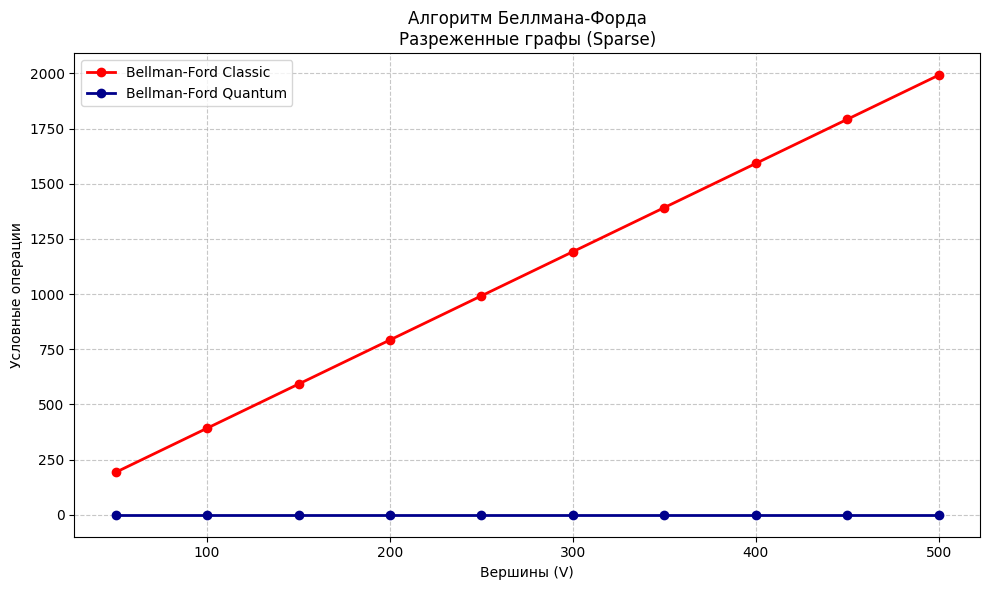

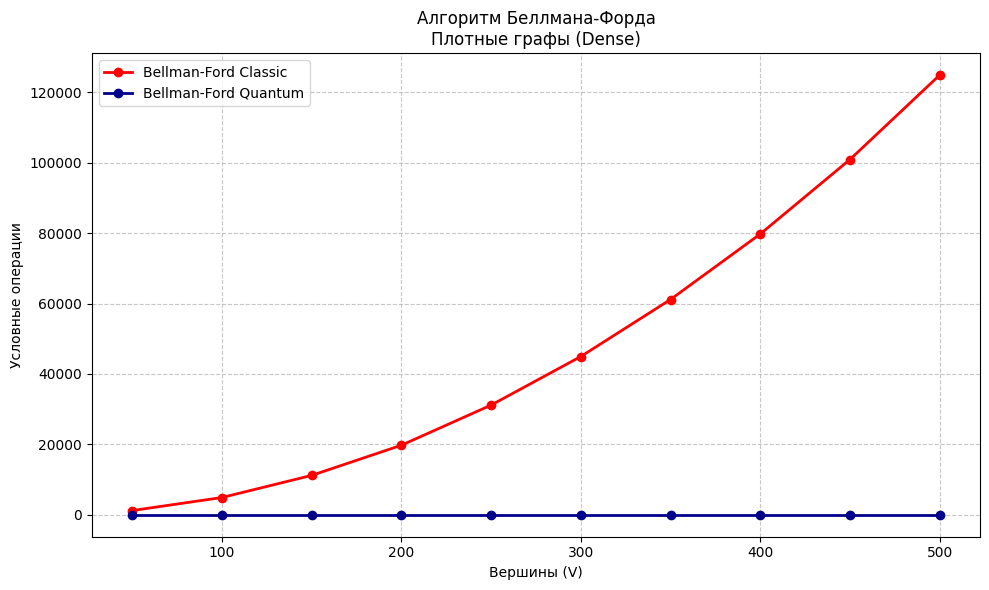

In [21]:
plot_results(res_bf, title_prefix="Алгоритм Беллмана-Форда")

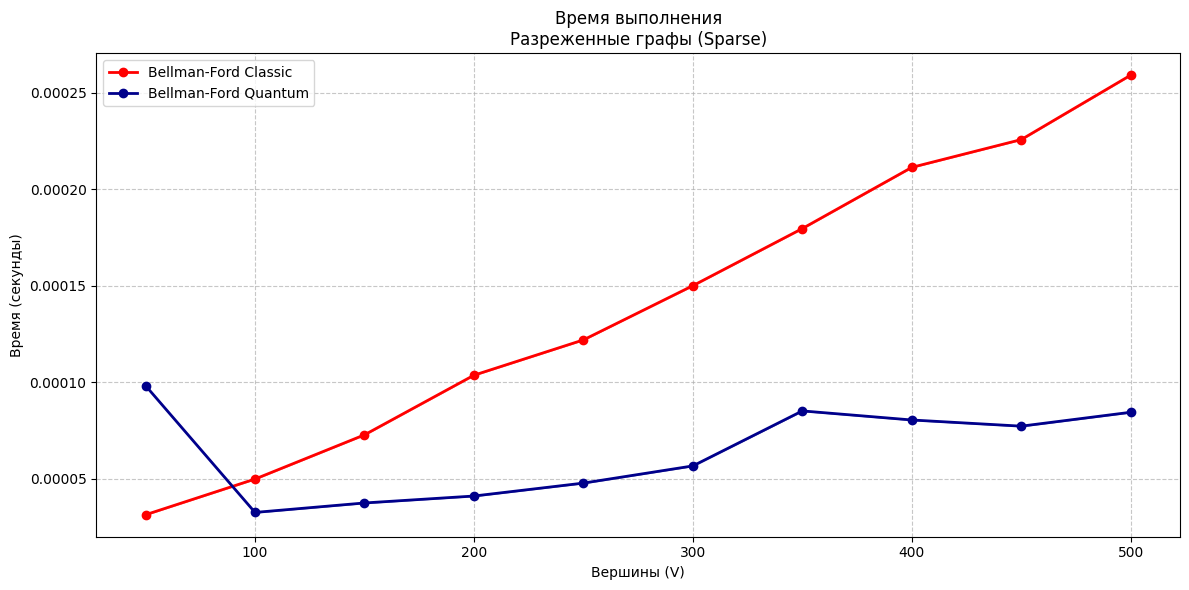

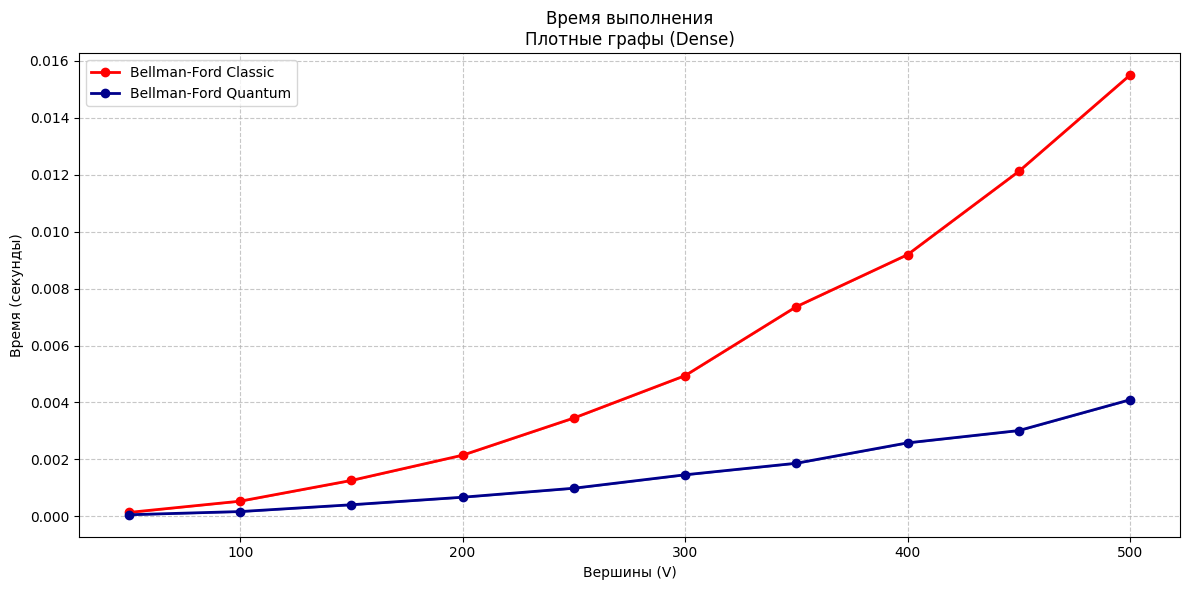

In [22]:
plot_time(res_bf)